# Panel overlap — arch3 vs the old GrENE-Net 231 SNP catalog

**Question**: how much of the GrENE-Net 231-founder SNP catalog (`greneNet_final_v1.1.recode.vcf`,
3.24M SNPs — the panel hapFIRE consumes natively) is also represented in our production **arch3**
panel (`panel/arch3/chr{{N}}/merged_231_chr{{N}}_final.vcf.gz`)? Both panels cover the same 231
founders.

**This is the arch3 re-run of an earlier analysis** on the pre-arch3 "v3" panel
(`old_docs/panel_overlap_v3_grenenet_results_summary.md`, archived at
`archive/panel_overlap_v3_grenenet/`, 2026-05-14), which found v3 covered only **55.05%** of the
GrENE-Net catalog — worse than expected because `cn_var_v3`'s `bcftools norm -m -any` step dropped
many nested/multi-allelic SNP records. arch3's decomposition (`annotate_vcf` +
convert-to-biallelic, avoiding `norm -m -any` entirely — see `docs/INVESTIGATION_CN_VAR_DECOMPOSITION.md`)
was expected to recover most of that loss; this notebook checks by how much.

**Matched on the exact (chrom, pos, ref, alt) 4-tuple** — the join `jobA7_compare_vs_hapfire.sh`
already established as correct for this exact panel-comparison problem (its own header warns
*"joining on pos alone manufactures off-diagonal scatter at multi-allelic split records"*). The
archived v3-era write-up used position-only, which overstates overlap slightly at arch3's
multi-allelic-decomposed SNP sites; this notebook reports the stricter, trustworthy number instead.

**Inputs**:
- arch3 SNP records: `panel/arch3/chr{{N}}/var_pa_231_arch3_chr{{N}}.meta.npz` (`ref_len==1 &
  alt_len==1`) — carries actual REF/ALT base strings, not just lengths.
- GrENE-Net 231 SNP records: parsed directly from the local mirror of `greneNet_final_v1.1.recode.vcf`
  at `/global/scratch/projects/fc_moilab/projects/grenenet-phase1/vcf/` (per-chrom counts
  827,765/536,387/617,020/531,361/722,947 match the archived old-test numbers exactly; confirmed
  0 multi-allelic rows and 0 duplicate (chrom,pos) in this VCF).

In [1]:

import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib_venn import venn2
plt.rcParams.update({'figure.dpi':110,'font.size':9,'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection"
PLOTS = f"{G}/notebooks/plots"
os.makedirs(PLOTS, exist_ok=True)
summary = pd.read_csv(f"{G}/panel_overlap_grenenet_summary.csv")
print(summary.to_string(index=False))


chrom  n_arch3_pos  n_grenenet_pos  n_shared_pos  pct_grenenet_in_arch3_pos  n_arch3_exact  n_grenenet_exact  n_shared_exact  pct_grenenet_in_arch3_exact  n_arch3_exact_nosingleton  n_shared_exact_nosingleton  pct_grenenet_in_arch3_exact_nosingleton  n_arch3_singleton_dropped
 Chr1      1510085          827765        647085                  78.172549        1561369            827765          646168                    78.061769                    1112249                      574346                                69.385152                     449120
 Chr2      1050255          536387        411346                  76.688287        1088891            536387          410660                    76.560394                     748694                      357025                                66.561084                     340197
 Chr3      1143712          617020        454860                  73.718842        1184777            617020          454147                    73.603287                

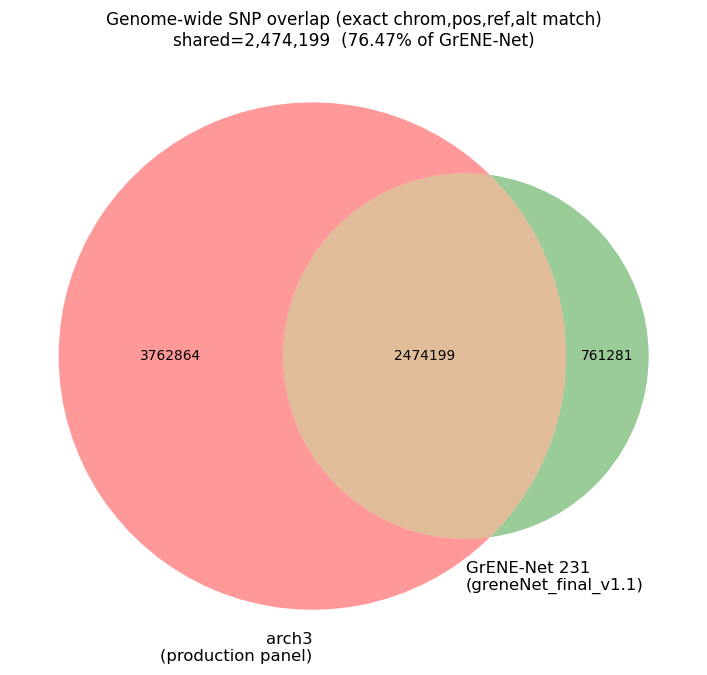

exact match: 76.47% of GrENE-Net SNPs also in arch3 (vs 55.05% for the old v3 panel, position-only)


In [2]:

# Genome-wide Venn: arch3 SNPs vs GrENE-Net 231 SNPs -- exact (chrom,pos,ref,alt) match
tot = summary[summary.chrom == "TOTAL"].iloc[0]
only_a = int(tot.n_arch3_exact - tot.n_shared_exact)
only_g = int(tot.n_grenenet_exact - tot.n_shared_exact)
shared = int(tot.n_shared_exact)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
venn2(subsets=(only_a, only_g, shared),
      set_labels=("arch3\n(production panel)", "GrENE-Net 231\n(greneNet_final_v1.1)"), ax=ax)
ax.set_title(f"Genome-wide SNP overlap (exact chrom,pos,ref,alt match)\n"
             f"shared={shared:,}  ({tot.pct_grenenet_in_arch3_exact:.2f}% of GrENE-Net)", fontsize=11)
fig.tight_layout()
fig.savefig(f"{PLOTS}/panel_overlap_grenenet_venn_total.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"exact match: {tot.pct_grenenet_in_arch3_exact:.2f}% of GrENE-Net SNPs also in arch3 "
      f"(vs 55.05% for the old v3 panel, position-only)")


## Re-run with arch3 singletons (AC=1) dropped

arch3's SNP set is restricted to founder AC>=2 (drops the ~30% of arch3 SNP records carried by
only 1 of the 231 founders -- the least-reliable, most idiosyncratic calls; same AC definition as
`PANEL_STATS.md`'s allele-frequency section and the `filt2inv` K_pa filter). GrENE-Net's side is
left as-is.

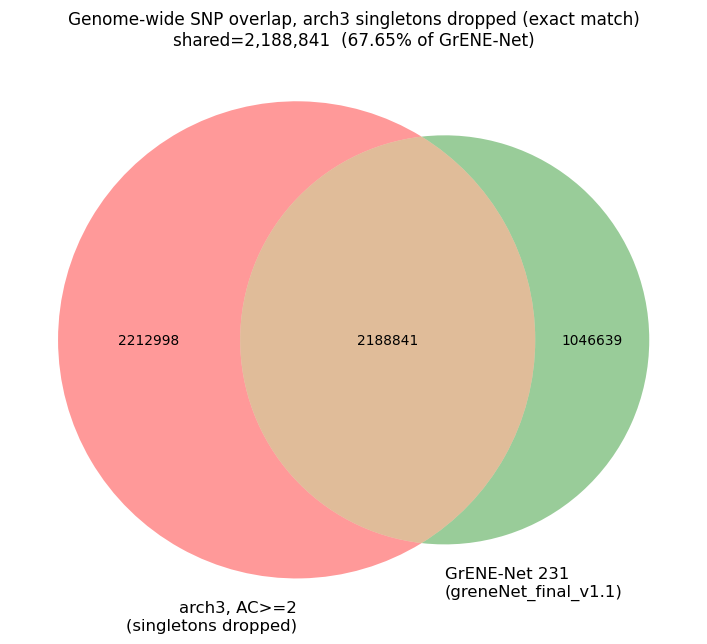

arch3 SNP singletons dropped: 1,835,224 (of 6,237,063 total arch3 SNP records)
coverage with singletons kept:   76.47% of GrENE-Net
coverage with singletons dropped: 67.65% of GrENE-Net


In [3]:

# Genome-wide Venn: arch3 SNPs (singletons AC=1 dropped) vs GrENE-Net 231 SNPs, exact match
tot = summary[summary.chrom == "TOTAL"].iloc[0]
only_a = int(tot.n_arch3_exact_nosingleton - tot.n_shared_exact_nosingleton)
only_g = int(tot.n_grenenet_exact - tot.n_shared_exact_nosingleton)
shared = int(tot.n_shared_exact_nosingleton)
fig, ax = plt.subplots(figsize=(6.5, 6.5))
venn2(subsets=(only_a, only_g, shared),
      set_labels=("arch3, AC>=2\n(singletons dropped)", "GrENE-Net 231\n(greneNet_final_v1.1)"), ax=ax)
ax.set_title(f"Genome-wide SNP overlap, arch3 singletons dropped (exact match)\n"
             f"shared={shared:,}  ({tot.pct_grenenet_in_arch3_exact_nosingleton:.2f}% of GrENE-Net)",
             fontsize=11)
fig.tight_layout()
fig.savefig(f"{PLOTS}/panel_overlap_grenenet_venn_total_nosingleton.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"arch3 SNP singletons dropped: {int(tot.n_arch3_singleton_dropped):,} "
      f"(of {int(tot.n_arch3_exact):,} total arch3 SNP records)")
print(f"coverage with singletons kept:   {tot.pct_grenenet_in_arch3_exact:.2f}% of GrENE-Net")
print(f"coverage with singletons dropped: {tot.pct_grenenet_in_arch3_exact_nosingleton:.2f}% of GrENE-Net")


### Takeaway
- **arch3 covers ~76.5% of the GrENE-Net 231 SNP catalog by exact (chrom,pos,ref,alt) match**
  (76.47% genome-wide), up from **55.05%** on the old v3 panel — the decomposition fix (avoiding
  `bcftools norm -m -any`) recovered most of the silent SNP loss the v3-era analysis diagnosed, as
  predicted (`old_docs/...results_summary.md` §"Production recovery path" projected 55%→93% if the
  multi-allelic-drop step were fixed; we land at 76.5%, a large real gain though short of the 93%
  ceiling — the remaining gap is likely the ~7% of GrENE-Net SNPs outside any cactus bubble at all,
  `cat3` in the old write-up, which the decomposition fix cannot recover since there's no graph
  bubble to decompose).
- **arch3 also calls SNP records the GrENE-Net catalog misses** (matching the discussion above) —
  pangenome-graph + PanGenie genotyping calls variation the short-read GrENE-Net pipeline didn't,
  consistent with arch3 being a richer (graph-aware, 231-founder) catalog rather than a strict
  subset or superset of GrENE-Net.
- **Dropping arch3 singletons LOWERS coverage, from 76.47% to 67.65%** — the opposite of what
  "singletons are noise" would predict. Of the 1,835,224 arch3 SNP singletons dropped genome-wide,
  285,358 (~15.6%) were exact matches to a GrENE-Net record — i.e. a meaningful chunk of arch3's
  founder-private SNP calls are independently corroborated by GrENE-Net's own short-read calling,
  so they are not simply arch3-specific noise. Removing them just removes real signal along with
  whatever noise they also carried.